# 05 — Logits, Softmax, Cross-Entropy, and What “Error” Really Means

A classifier's output layer produces logits. Softmax converts them into a normalized probability distribution:

$$
p_k=\frac{e^{z_k}}{\sum_j e^{z_j}}.
$$

For the true class $y$, sparse categorical cross-entropy is

$$
\mathcal L=-\log p_y.
$$

The loss is not merely “right or wrong.” It penalizes **confidence assigned away from the correct class**.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)


In [2]:
import torch
import torch.nn.functional as F
logits = torch.tensor([[1.2, -0.2, 2.1, 0.4]], dtype=torch.float32)
target = torch.tensor([2])
probs = torch.softmax(logits, dim=1)
loss = F.cross_entropy(logits, target)
manual = -torch.log(probs[0, target.item()])
print('probabilities:', probs)
print('target probability:', probs[0,target.item()].item())
print('framework CE:', loss.item())
print('manual -log(p_target):', manual.item())


probabilities: tensor([[0.2406, 0.0593, 0.5919, 0.1081]])
target probability: 0.5918868780136108
framework CE: 0.5244397521018982
manual -log(p_target): 0.5244397521018982


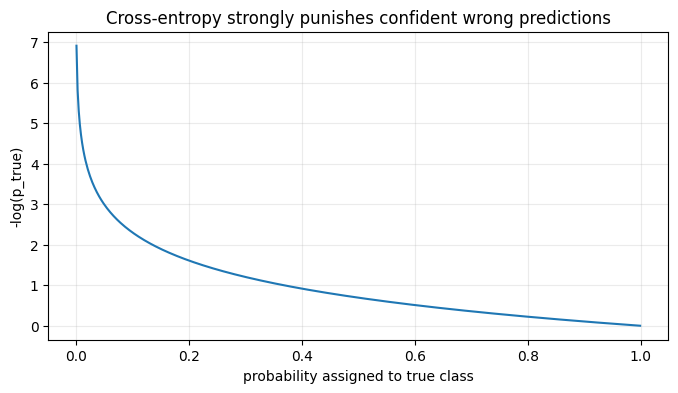

In [3]:
p = np.linspace(0.001,0.999,500)
loss = -np.log(p)
plt.figure(figsize=(8,4))
plt.plot(p,loss)
plt.xlabel('probability assigned to true class')
plt.ylabel('-log(p_true)')
plt.title('Cross-entropy strongly punishes confident wrong predictions')
plt.grid(alpha=.25); plt.show()


## Business interpretation

Two models can have identical accuracy while assigning very different confidence. Confidence matters when predictions drive thresholds, human review, pricing, routing, or risk controls. Therefore accuracy alone is not an adequate production metric.

### Why logits are often preferred internally

Softmax probabilities look intuitive, but logits preserve the unconstrained evidence produced by the network. Training APIs usually combine log-softmax and cross-entropy into one numerically stable operation. This avoids separately exponentiating very large numbers and then taking logarithms again. In engineering terms, the mathematically equivalent formulation is not always the numerically equivalent implementation.

### Error severity

If the true class receives probability 0.9, the loss is small. If it receives 0.01, the loss is much larger. Cross-entropy therefore distinguishes a near miss from a confidently wrong prediction even when both count as a single classification error under accuracy. That property is one reason it is useful for gradient-based learning.
